In [1]:
import os
import numpy as np
import scanpy as sc
import squidpy as sq
from anndata import AnnData
import scipy.sparse as sp
import warnings
warnings.filterwarnings('ignore')
import os
import pandas as pd
import matplotlib.pyplot as plt
def format_data_neighs_colapse(
    adata: AnnData,
    spatial_key: str = "spatial",
    neighs: int = 10
) -> AnnData:
    """Pseudobin each cell’s expression by summing over its spatial neighbors."""
    if spatial_key not in adata.obsm:
        coords = adata.obs[['X','Y']].values.astype(float)
        adata.obsm[spatial_key] = coords

    ad = adata.copy()
    print(f"    → Computing spatial neighbors (k={neighs})…", end="", flush=True)
    sq.gr.spatial_neighbors(ad, spatial_key=spatial_key, n_neighs=neighs)
    print("done")

    C = ad.obsp['spatial_connectivities'].astype(bool).astype(int)
    C = C + sp.eye(C.shape[0], format='csr')
    X = ad.X.copy() if not isinstance(ad.X, np.ndarray) else ad.X
    Xc = C.dot(X)

    print("    → Pseudobinning complete")
    return AnnData(
        X    = Xc,
        obs  = ad.obs.copy(),
        var  = ad.var.copy(),
        obsm = ad.obsm.copy(),
        uns  = ad.uns.copy()
    )


def domains_by_rbd(
    adata: AnnData,
    hyperparams: dict,
    sample_key: str = 'sample',
    cell_id_key: str = None,
    checkpoint_dir: str = './checkpoints',
    force_rerun: bool = False
) -> (AnnData, AnnData):
    """
    Read-based domains with checkpointed saves, force-rerun option, and printouts.
    """
    os.makedirs(checkpoint_dir, exist_ok=True)

    # A) ensure unique IDs
    if cell_id_key is None:
        print("1) Ensuring unique cell IDs…", end="", flush=True)
        adata.obs_names_make_unique()
        cell_id_key = 'cell_id'
        adata.obs[cell_id_key] = adata.obs_names
        print("done\n")

    def load_or_compute(path, compute_fn, step_name):
        if (not force_rerun) and os.path.exists(path):
            print(f"{step_name}: Loading from checkpoint…", end="", flush=True)
            ad = sc.read_h5ad(path)
            print("loaded\n")
            return ad, False
        else:
            print(f"{step_name}: Computing…", flush=True)
            ad = compute_fn()
            ad.write_h5ad(path)
            print(f"{step_name}: Saved to {path}\n")
            return ad, True

    # 1) PSEUDOBINNING
    pseudobin_path = os.path.join(checkpoint_dir, 'pseudobinned.h5ad')
    def compute_pseudobin():
        parts = []
        for samp in adata.obs[sample_key].unique():
            print(f"  Sample '{samp}':")
            sub = adata[adata.obs[sample_key] == samp].copy()
            parts.append(format_data_neighs_colapse(
                sub, spatial_key='spatial', neighs=hyperparams['neighbors']
            ))
        return sc.concat(parts, merge='same')

    pseudobinned, _ = load_or_compute(
        pseudobin_path, compute_pseudobin, "Step 1) Pseudobinning"
    )

    # 2) FILTERING
    filtered_path = os.path.join(checkpoint_dir, 'filtered.h5ad')
    def compute_filtered():
        ad_neigh = pseudobinned.copy()
        ad_neigh.X = np.nan_to_num(ad_neigh.X)
        sc.pp.filter_cells(ad_neigh, min_counts=4)
        ad_neigh.raw = ad_neigh
        return ad_neigh

    adata_neigh, _ = load_or_compute(
        filtered_path, compute_filtered, "Step 2) Filtering"
    )

    # 3) UMAP
    umap_path = os.path.join(checkpoint_dir, 'umap.h5ad')
    def compute_umap():
        nn  = hyperparams.get('n_neighbors', 20)
        pcs = hyperparams.get('n_pcs', None)
        if pcs is None:
            sc.pp.neighbors(adata_neigh, n_neighbors=nn, use_rep='X')
        else:
            sc.tl.pca(adata_neigh, n_comps=pcs, svd_solver='arpack')
            sc.pp.neighbors(adata_neigh, n_neighbors=nn, n_pcs=pcs)
        sc.tl.umap(adata_neigh, min_dist=hyperparams.get('min_dist',0.1))
        return adata_neigh

    adata_neigh, _ = load_or_compute(
        umap_path, compute_umap, "Step 3) UMAP"
    )

    # 4) CLUSTERING at one or many resolutions
    algo = hyperparams['clustering_algorithm'].lower()
    res_list = hyperparams.get('resolutions',
               [hyperparams.get('resolution')])

    for res in res_list:
        key = f"rbd_domain_{res}"
        chk = os.path.join(checkpoint_dir, f"clustered_{res}.h5ad")

        def compute_cluster():
            if algo == 'leiden':
                sc.tl.leiden(adata_neigh, resolution=res, key_added=key)
            else:
                sc.tl.louvain(adata_neigh, resolution=res, key_added=key)
            return adata_neigh

        adata_neigh, _ = load_or_compute(
            chk, compute_cluster,
            f"Step 4) Clustering (res={res})"
        )

        # map back to original
        print(f"  → Mapping rbd_domain_{res} back to original…", end="", flush=True)
        mapping = dict(zip(
            adata_neigh.obs[cell_id_key],
            adata_neigh.obs[key]
        ))
        adata.obs[key] = adata.obs[cell_id_key].map(mapping).astype(str)
        print("done\n")

    print("All steps complete! Returning results.")
    return adata, adata_neigh

hyperparams = {
    'neighbors': 20,
    'clustering_algorithm': 'leiden',
    'resolutions': [0.1, 0.2, 0.5, 1.0],
    'n_neighbors': 20,
    'n_pcs': 30,
    'min_dist': 0.5
}

In [2]:
adata_sub = sc.read_h5ad('../data/mtDNA_DSB_5k_clustered_manual_annotation.h5ad')

In [3]:
adata_sub.obs['cell_id'] = adata_sub.obs.index

In [4]:
adata_sub = adata_sub[adata_sub.obs.condition == 'mtDSB']

In [5]:
adata_sub = adata_sub[adata_sub.obs.age=='60']

In [6]:
adata_sub.obs.sample_id.unique()

['RB4401', 'RB4403', 'RB4405']
Categories (3, object): ['RB4401', 'RB4403', 'RB4405']

In [7]:
#adata_sub = adata_sub[adata_sub.obs.sex == 'male']

In [8]:
# 3) Call domains_by_rbd, forcing a fresh run
adata_annotated, adata_pseudobinned = domains_by_rbd(
    adata_sub,
    hyperparams,
    sample_key='sample_id',
    cell_id_key='cell_id',               # or whatever your unique-ID column is
    checkpoint_dir='../results/rbd_checkpoints_mtDSB',  # where to store (or load) .h5ad files
    force_rerun=True                     # overwrite any existing checkpoints
)

Step 1) Pseudobinning: Computing…
  Sample 'RB4401':
    → Computing spatial neighbors (k=20)…done
    → Pseudobinning complete
  Sample 'RB4403':
    → Computing spatial neighbors (k=20)…done
    → Pseudobinning complete
  Sample 'RB4405':
    → Computing spatial neighbors (k=20)…done
    → Pseudobinning complete
Step 1) Pseudobinning: Saved to ../results/rbd_checkpoints_mtDSB/pseudobinned.h5ad

Step 2) Filtering: Computing…
Step 2) Filtering: Saved to ../results/rbd_checkpoints_mtDSB/filtered.h5ad

Step 3) UMAP: Computing…
Step 3) UMAP: Saved to ../results/rbd_checkpoints_mtDSB/umap.h5ad

Step 4) Clustering (res=0.1): Computing…
Step 4) Clustering (res=0.1): Saved to ../results/rbd_checkpoints_mtDSB/clustered_0.1.h5ad

  → Mapping rbd_domain_0.1 back to original…done

Step 4) Clustering (res=0.2): Computing…
Step 4) Clustering (res=0.2): Saved to ../results/rbd_checkpoints_mtDSB/clustered_0.2.h5ad

  → Mapping rbd_domain_0.2 back to original…done

Step 4) Clustering (res=0.5): Comput

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec

def plot_spatial_compact(
    ad,
    color="leiden_2",
    groupby="sample_id",
    spot_size=18,
    cols=3,
    height=8,
    legend_col_width=1.2,
    palette=None,          # <- NEW: dict {category: "#hex"} or list in desired order
):
    # --- categories from the FULL object (freeze order) ---
    cats = ad.obs[color].astype("category").cat.categories

    # --- build a shared color list in that order ---
    if isinstance(palette, dict):
        cols_list = [palette[c] for c in cats]
    elif isinstance(palette, (list, tuple)):
        if len(palette) < len(cats):
            raise ValueError("Palette list shorter than number of categories.")
        cols_list = list(palette)[:len(cats)]
    elif f"{color}_colors" in ad.uns:
        # reuse existing palette if present on the full object
        cols_list = list(ad.uns[f"{color}_colors"])
        if len(cols_list) != len(cats):
            raise ValueError(f"{color}_colors length does not match categories.")
    else:
        base = sc.pl.palettes.default_64 if hasattr(sc.pl.palettes, "default_64") else sc.pl.palettes.default_102
        reps = int(np.ceil(len(cats) / len(base)))
        cols_list = (base * reps)[:len(cats)]

    # store on the full object too (handy if you plot elsewhere later)
    ad.uns[f"{color}_colors"] = cols_list

    # --- layout ---
    sids = list(ad.obs[groupby].unique())
    n = len(sids)
    rows = int(np.ceil(n / cols))

    panel_w = height * cols * 0.6 / rows
    fig_w = panel_w + legend_col_width
    fig = plt.figure(figsize=(fig_w, height), constrained_layout=False)

    gs = GridSpec(
        rows, cols + 1, figure=fig,
        width_ratios=[1]*cols + [legend_col_width / (fig_w - legend_col_width)],
        wspace=0.02, hspace=0.02
    )

    # --- panels ---
    for i, sid in enumerate(sids):
        r, c = divmod(i, cols)
        ax = fig.add_subplot(gs[r, c])

        ad_sub = ad[ad.obs[groupby] == sid].copy()

        # CRUCIAL: force identical categories & palette on each subset
        ad_sub.obs[color] = ad_sub.obs[color].astype("category")
        ad_sub.obs[color] = ad_sub.obs[color].cat.set_categories(cats)
        ad_sub.uns[f"{color}_colors"] = cols_list

        sc.pl.spatial(
            ad_sub, color=color, spot_size=spot_size,
            show=False, ax=ax, legend_loc=None, frameon=False, title=str(sid)
        )
        ax.set_xlabel(""); ax.set_ylabel("")
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    # blank unused
    for j in range(n, rows*cols):
        r, c = divmod(j, cols)
        fig.add_subplot(gs[r, c]).axis("off")

    # --- legend ---
    ax_leg = fig.add_subplot(gs[:, -1])
    ax_leg.axis("off")
    handles = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=cols_list[k], markersize=7, label=str(cat))
        for k, cat in enumerate(cats)
    ]
    ax_leg.legend(handles=handles, title=color, frameon=False, loc="center left")

    fig.subplots_adjust(left=0.01, right=0.98, top=0.98, bottom=0.02, wspace=0.02, hspace=0.02)
    plt.show()

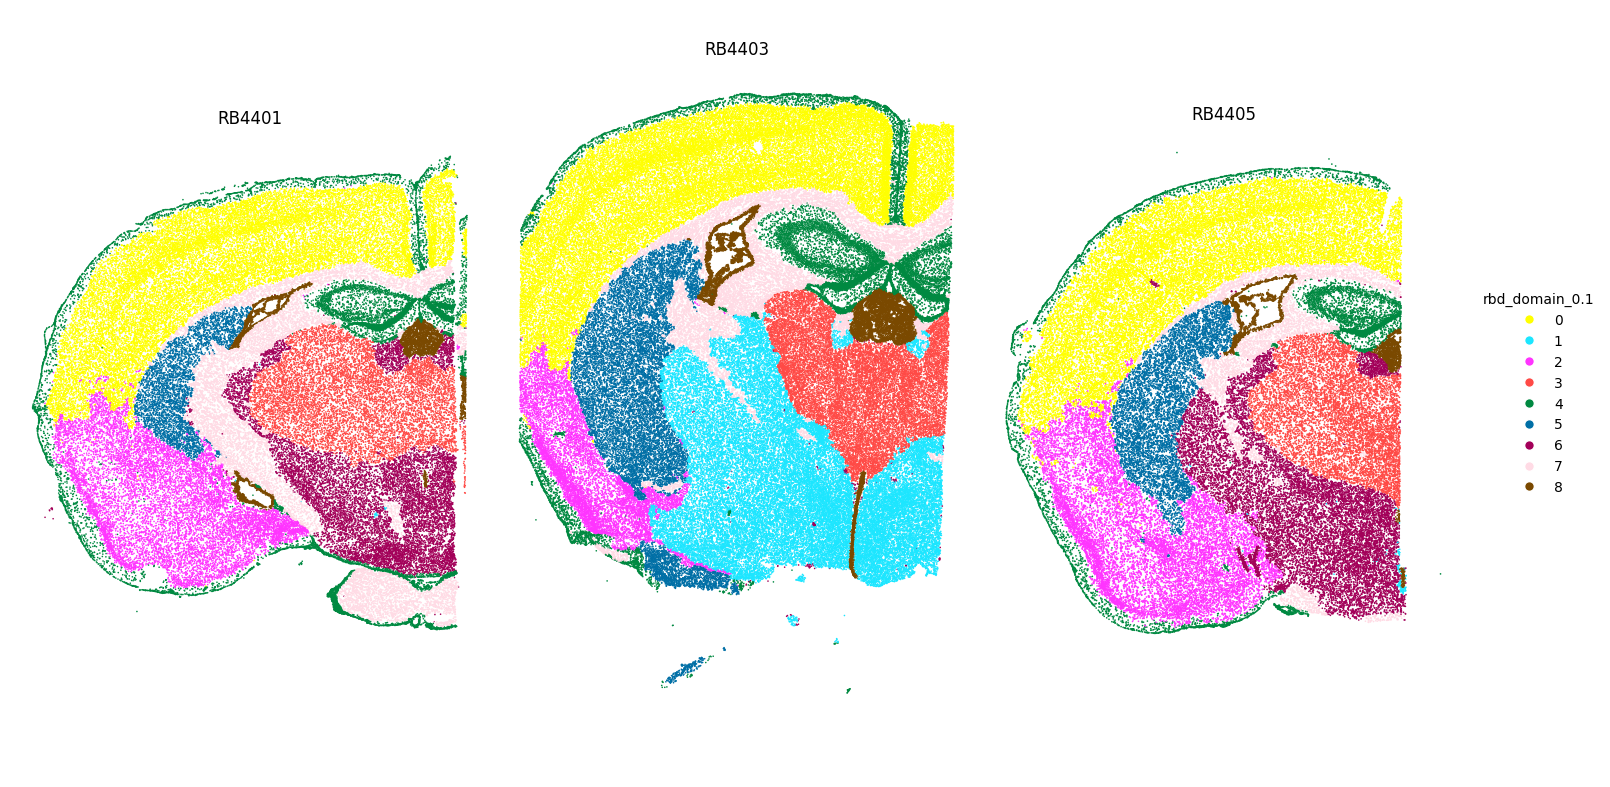

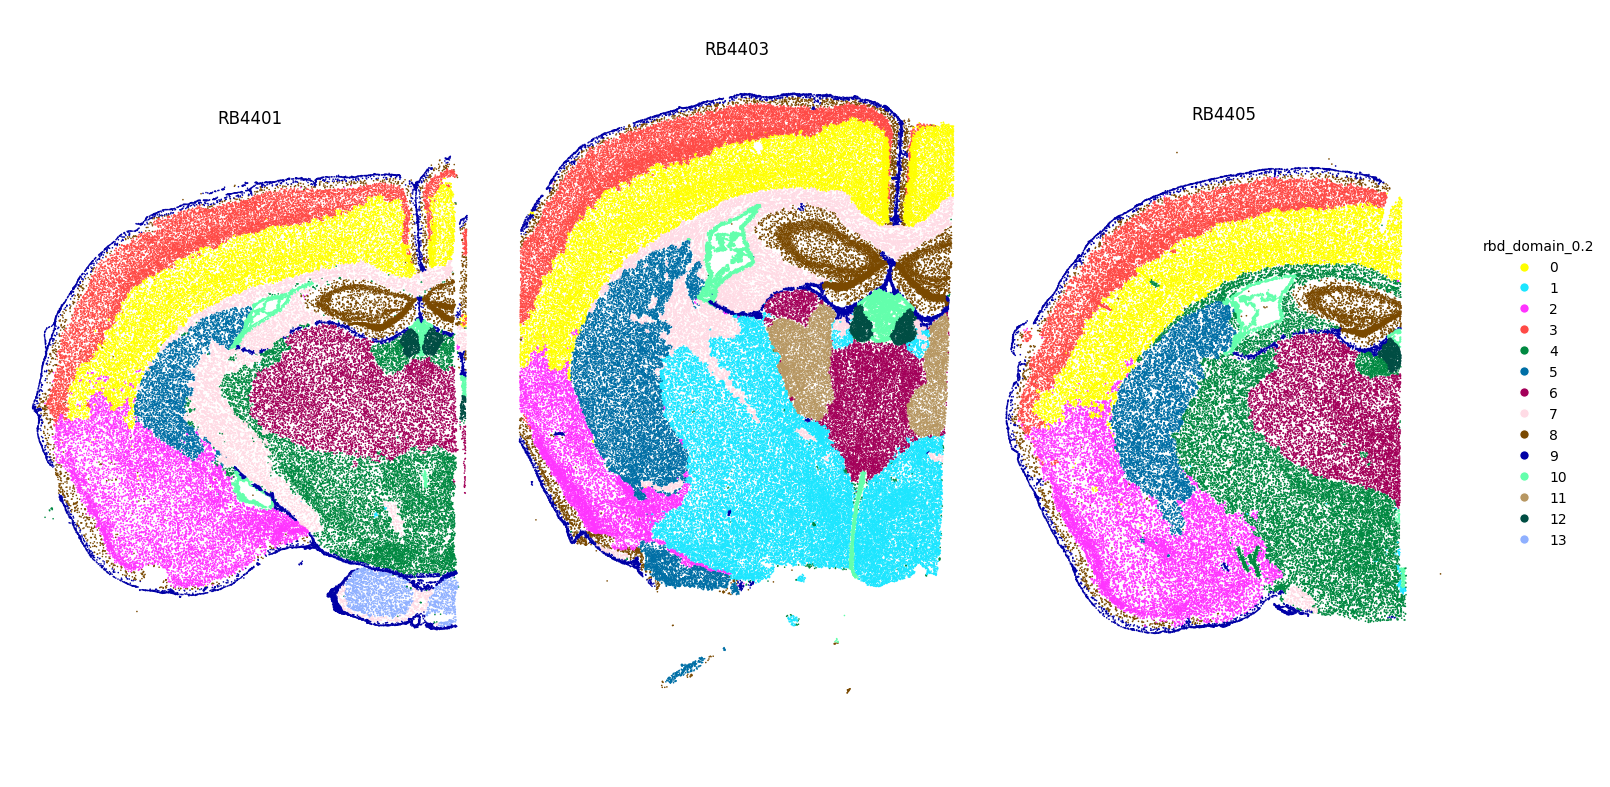

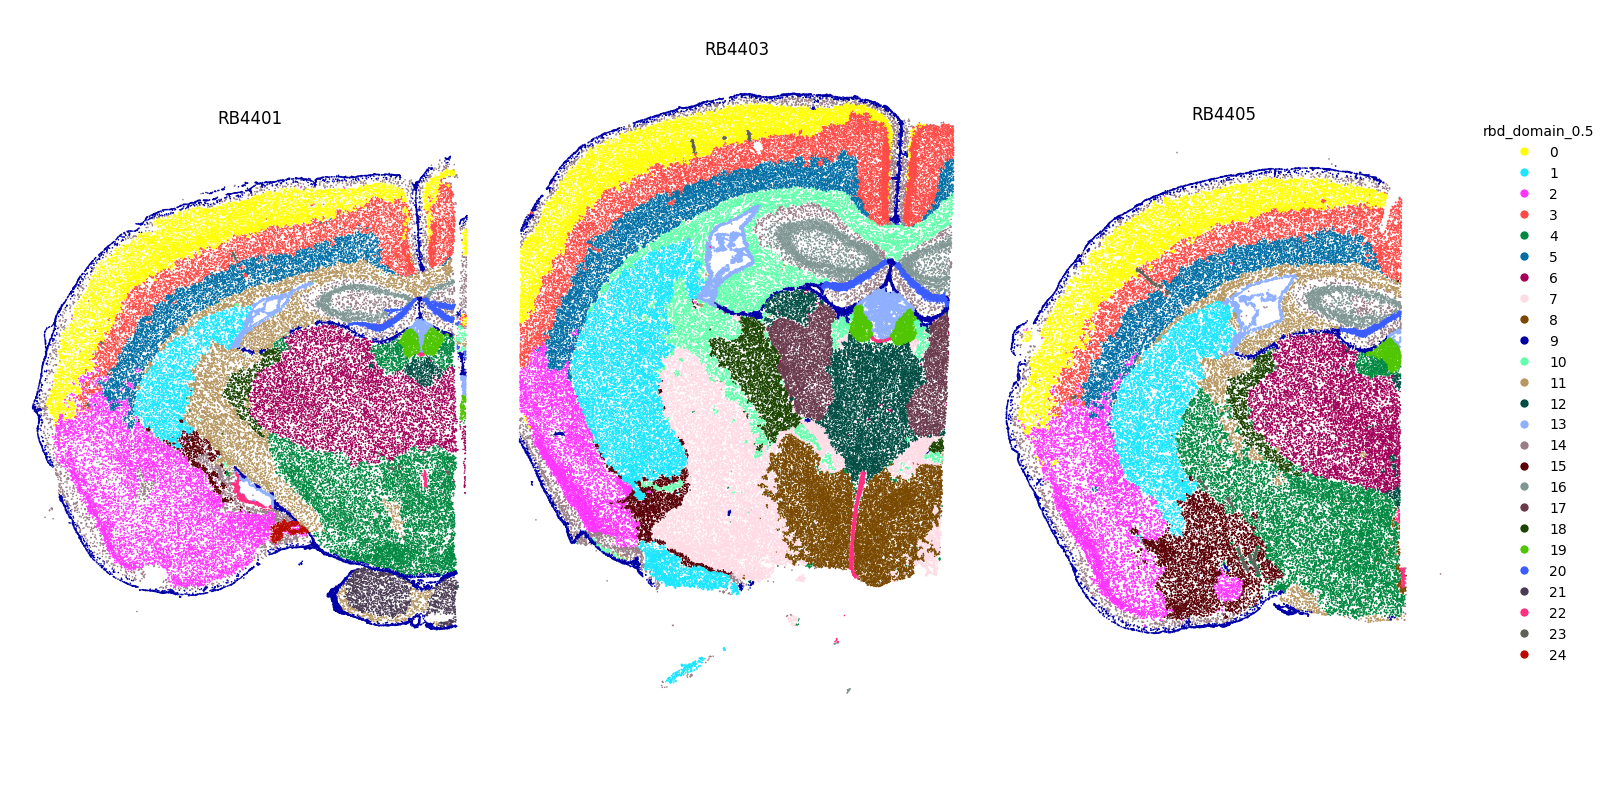

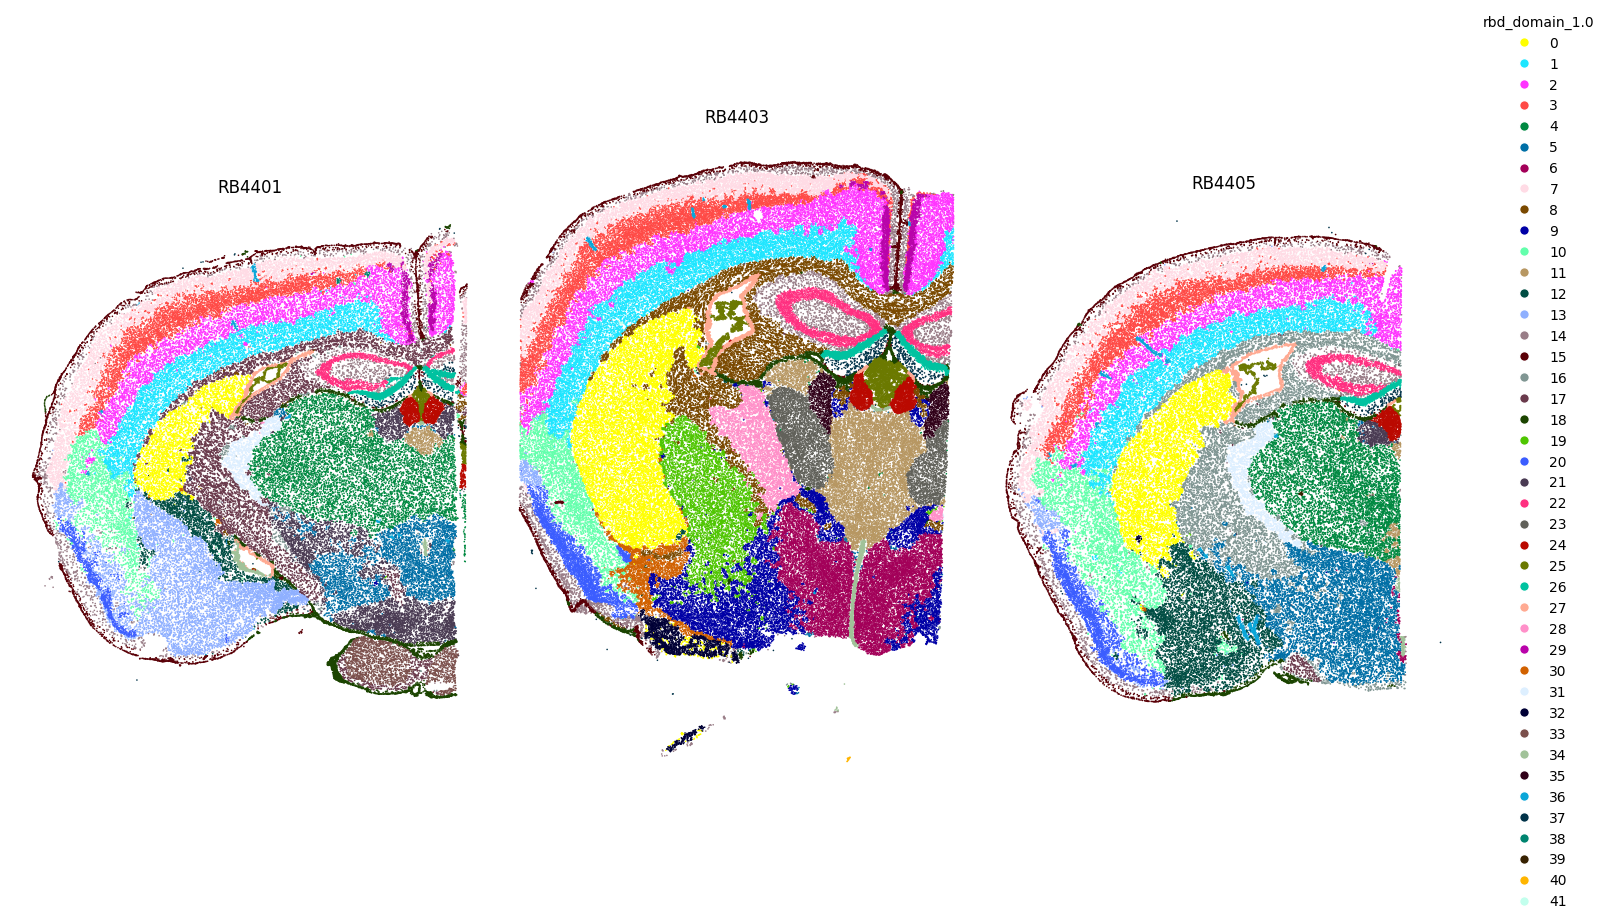

In [11]:
for domain in ['rbd_domain_0.1','rbd_domain_0.2','rbd_domain_0.5','rbd_domain_1.0',]:
    if domain in adata_pseudobinned.obs.columns: 
        plot_spatial_compact(adata_pseudobinned, color=domain, groupby="sample_id",spot_size=20,
            cols=3,
            height=8,
            legend_col_width=1.0,)
    else:
        continue

In [ ]:
sc.tl.rank_genes_groups(adata_pseudobinned, groupby='rbd_domain_0.5', method='t-test')


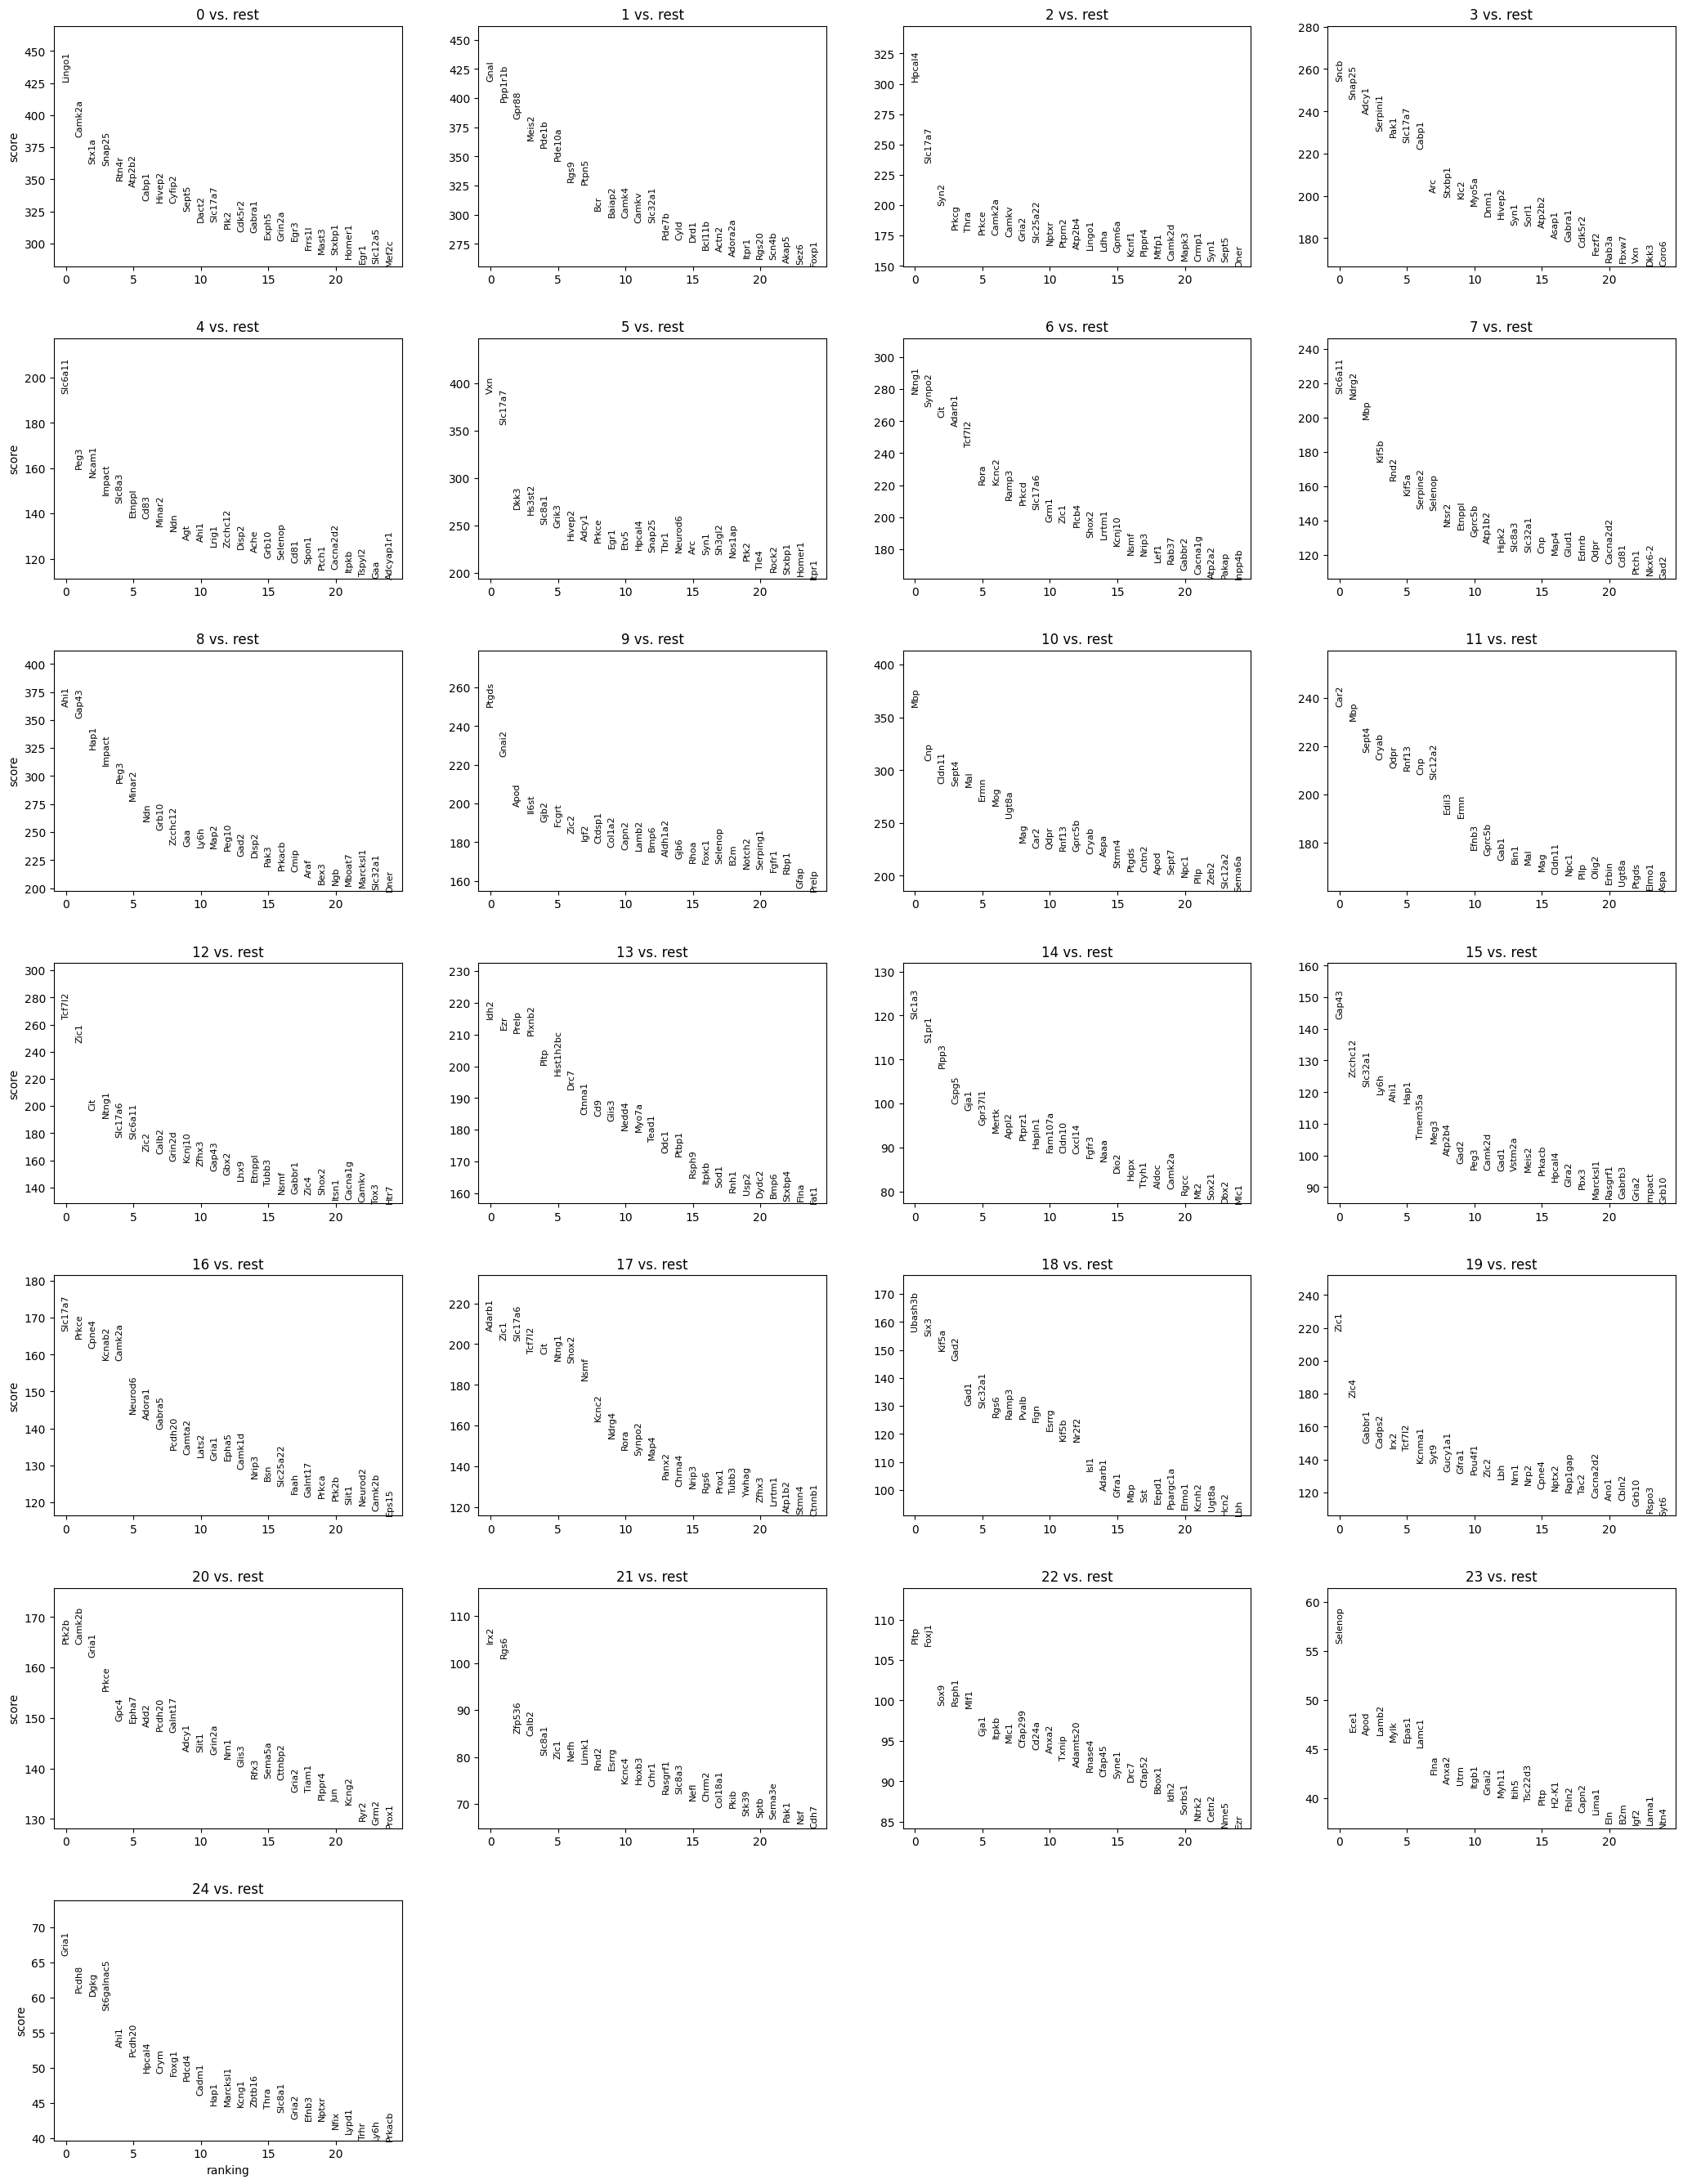

0
Lingo1 Camk2a Stx1a
 
1
Gnal Ppp1r1b Gpr88
 
2
Hpcal4 Slc17a7 Syn2
 
3
Sncb Snap25 Adcy1
 
4
Slc6a11 Peg3 Ncam1
 
5
Vxn Slc17a7 Dkk3
 
6
Ntng1 Synpo2 Cit
 
7
Slc6a11 Ndrg2 Mbp
 
8
Ahi1 Gap43 Hap1
 
9
Ptgds Gnai2 Apod
 
10
Mbp Cnp Cldn11
 
11
Car2 Mbp Sept4
 
12
Tcf7l2 Zic1 Cit
 
13
Idh2 Ezr Prelp
 
14
Slc1a3 S1pr1 Plpp3
 
15
Gap43 Zcchc12 Slc32a1
 
16
Slc17a7 Prkce Cpne4
 
17
Adarb1 Zic1 Slc17a6
 
18
Ubash3b Six3 Kif5a
 
19
Zic1 Zic4 Gabbr1
 
20
Ptk2b Camk2b Gria1
 
21
Irx2 Rgs6 Zfp536
 
22
Pltp Foxj1 Sox9
 
23
Selenop Ece1 Apod
 
24
Gria1 Pcdh8 Dgkg
 


In [64]:
# See top 5 marker genes per cluster
sc.pl.rank_genes_groups(adata_pseudobinned, n_genes=25, sharey=False)

marker_genes = pd.DataFrame({
    group: adata_pseudobinned.uns['rank_genes_groups']['names'][group][:3]
    for group in adata_pseudobinned.uns['rank_genes_groups']['names'].dtype.names
})
marker_genes.head()
#marker_genes.to_csv('../data/broad_markers_leiden0-5.csv')
for col in marker_genes.columns: 
    print(col)
    genes = marker_genes[col].tolist()
    print(" ".join(genes))
    print(' ')

In [37]:
isr_core_genes = [
    "Atf4", "Atf5", "Ddit3", "Trib3",
    "Gstp1", "Cryab", "Mt1", "Mt2", "Txnip", "Sgk1",
    "Rnf13", "Odc1", "Idh2", "Eif4ebp1", "Ppp1r1b", "Lamp1"
]

reactive_glial_genes = [
    "Gfap", "Slc1a3", "Gja1", "Ptgds", "Apod", "Il6st",
    "Aldh1a2", "Selenop", "Hapln1", "S1pr1", "Plpp3",
    "Cryab", "Rnf13", "Gstp1", "Sgk1", "Ermn", "Olig2",
    "Mbp", "Cnp", "Mal", "Cldn11", "Syk", "C3ar1", "Grn",
    "Ifih1", "Nlrc4", "C6", "B2m", "H2-K1", "Lamp1", "Txnip", 'Serpina3n'
]

oxidative_stress_genes = [
    "Mt1", "Mt2", "Selenop", "Gstp1", "Cryab", "Idh2", "Txnip",
    "Epas1", "Ndrg2", "Apod", "Aldh1a2", "Pltp", "Sgk1", "Gab1"
]

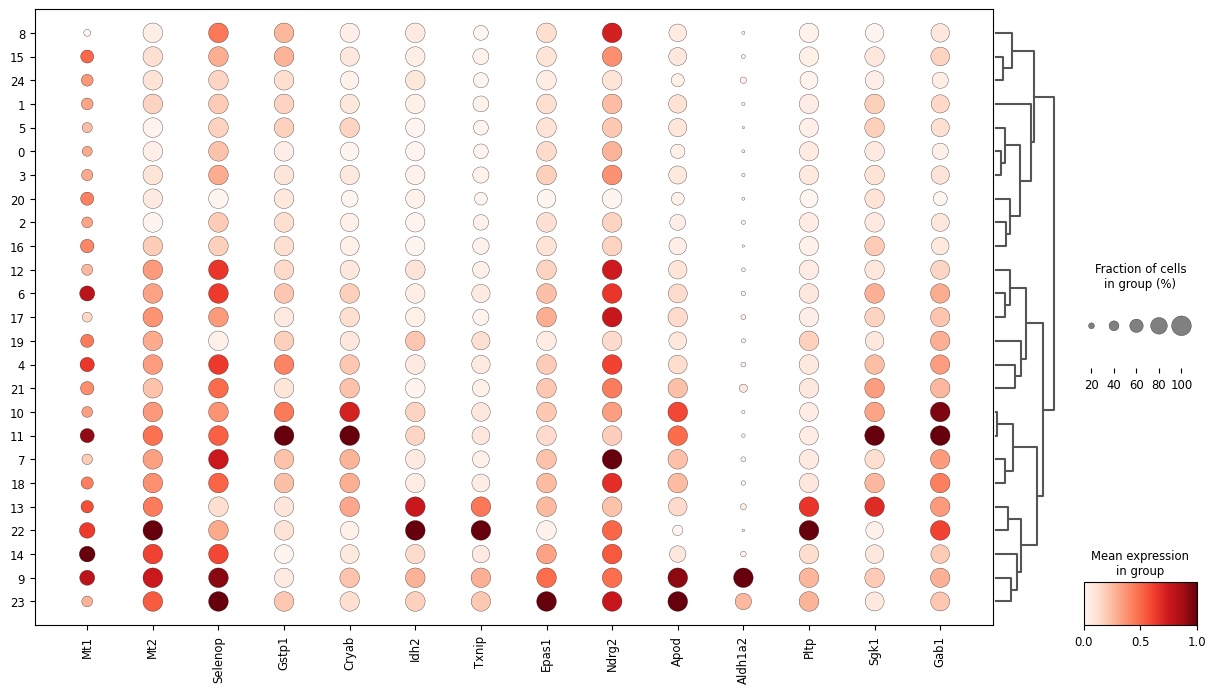

In [39]:
sc.pl.dotplot(
        adata_pseudobinned,
        var_names=oxidative_stress_genes,
        groupby="rbd_domain_0.5",
        standard_scale="var",
        #dot_max=0.5,
        #dot_min=0.05,
        color_map="Reds",
        
        dendrogram=True,
        figsize=(15, 8)
    )

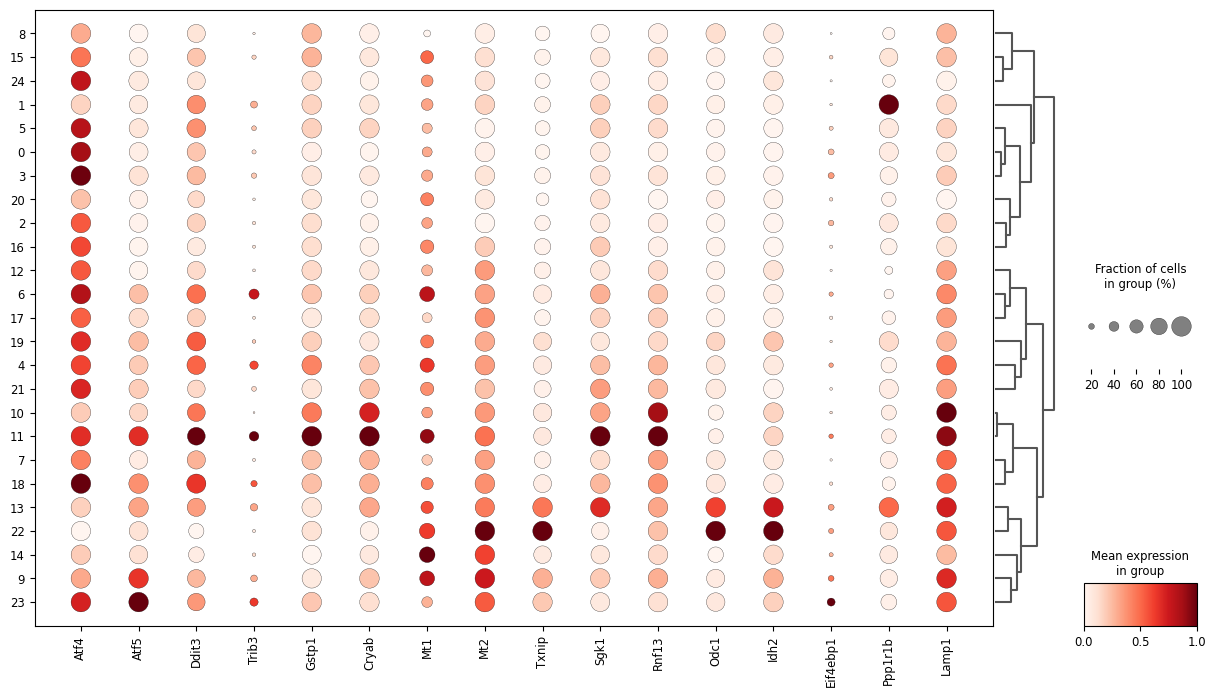

In [38]:
sc.pl.dotplot(
        adata_pseudobinned,
        var_names=isr_core_genes,
        groupby="rbd_domain_0.5",
        standard_scale="var",
        #dot_max=0.5,
        #dot_min=0.05,
        color_map="Reds",
        
        dendrogram=True,
        figsize=(15, 8)
    )

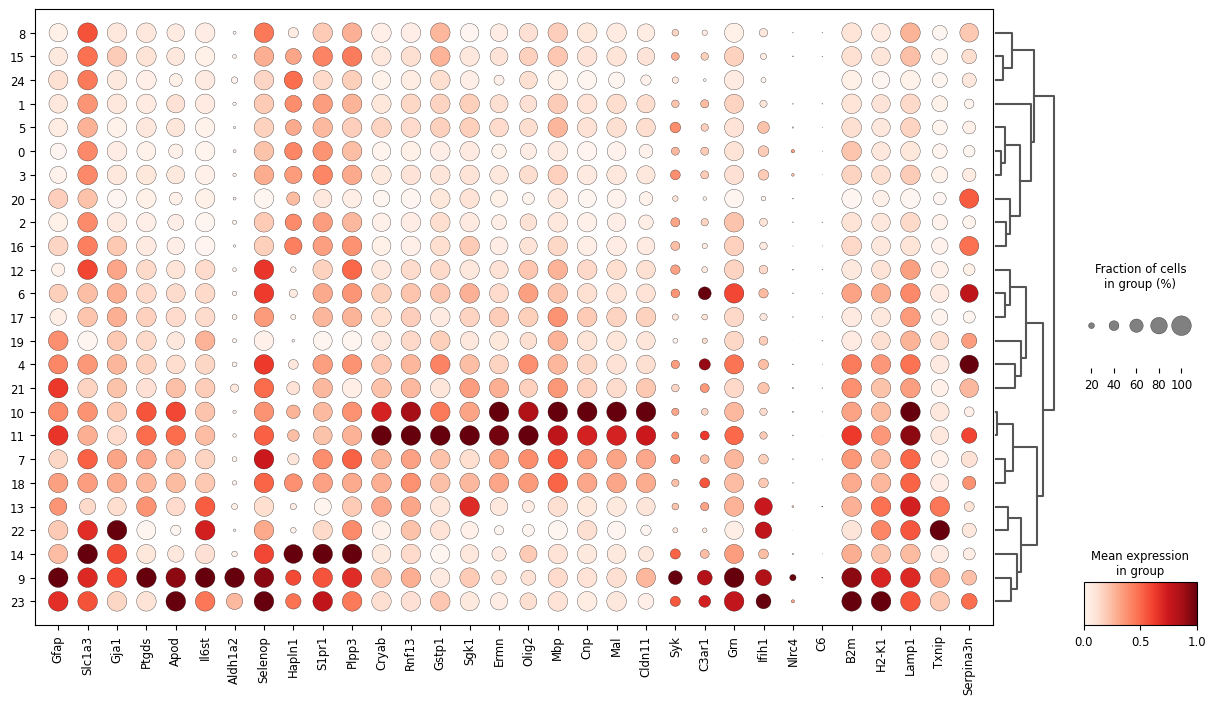

In [30]:
sc.pl.dotplot(
        adata_pseudobinned,
        var_names=reactive_glial_genes,
        groupby="rbd_domain_0.5",
        standard_scale="var",
        #dot_max=0.5,
        #dot_min=0.05,
        color_map="Reds",
        
        dendrogram=True,
        figsize=(15, 8)
    )

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize

def plot_spatial_genes_compact(
    ad,
    genes,
    groupby="sample_id",
    spot_size=18,
    cols=3,
    height=8,
    cmap="magma",          # any matplotlib colormap
    log1p=False,           # log1p-transform before plotting
    robust=True,           # use robust 2–98% limits instead of min/max
    vmin=None, vmax=None,  # override global color limits if you want
    nan_color="lightgray", # background for zero/NaN
    title_suffix="",
):
    """
    Plot per-sample spatial maps for one or multiple genes (continuous).
    Uses a shared color scale across all samples for each gene.
    """

    # ensure genes is a list
    genes = [genes] if isinstance(genes, str) else list(genes)
    sids  = list(ad.obs[groupby].unique())
    nS, nG = len(sids), len(genes)

    # grid: rows = samples, cols = genes + 1 legend column
    cols_total = nG + 1
    rows = int(np.ceil(nS))
    fig = plt.figure(figsize=(height * cols_total * 0.6, height), constrained_layout=False)
    gs  = GridSpec(rows, cols_total, figure=fig, width_ratios=[1]*nG + [0.25],
                   wspace=0.03, hspace=0.03)

    for gi, g in enumerate(genes):
        if g not in ad.var_names:
            print(f"⚠️ Gene '{g}' not in var_names; skipping.")
            continue

        # collect values across ALL samples to set shared limits
        vals = ad[:, g].X
        vals = vals.toarray().ravel() if hasattr(vals, "toarray") else np.asarray(vals).ravel()
        if log1p: vals = np.log1p(vals)

        if vmin is None or vmax is None:
            if robust:
                lo, hi = np.nanpercentile(vals, [2, 98])
            else:
                lo, hi = np.nanmin(vals), np.nanmax(vals)
        else:
            lo, hi = vmin, vmax
        if hi <= lo:  # degenerate case
            hi = lo + 1e-9
        norm = Normalize(vmin=lo, vmax=hi)

        # draw per-sample panels for this gene
        for si, sid in enumerate(sids):
            ax = fig.add_subplot(gs[si, gi]) if rows > 1 else fig.add_subplot(gs[0, gi])
            ad_sub = ad[ad.obs[groupby] == sid].copy()

            # precompute color values so Scanpy respects global norm
            v = ad_sub[:, g].X
            v = v.toarray().ravel() if hasattr(v, "toarray") else np.asarray(v).ravel()
            if log1p: v = np.log1p(v)
            # map to colors
            cmap_obj = plt.get_cmap(cmap)
            rgba = cmap_obj(norm(v))
            # make zeros / NaNs pale
            mask = ~np.isfinite(v) | (v <= 0)
            rgba[mask, :3] = plt.matplotlib.colors.to_rgb(nan_color)  # set color
            rgba[mask, 3]  = 1.0                                     # opaque

            # Scanpy trick: provide precomputed colors via obs (as hex)
            import matplotlib.colors as mcolors
            hex_colors = [mcolors.to_hex(c) for c in rgba]
            ad_sub.obs[f"__{g}__colors"] = hex_colors

            sc.pl.spatial(
                ad_sub,
                color=f"__{g}__colors",           # plot with our precomputed colors
                spot_size=spot_size,
                show=False,
                ax=ax,
                title=f"{sid}" + (f" • {title_suffix}" if title_suffix else ""),
                frameon=False,
                legend_loc=None,
            )
            ax.set_xlabel(""); ax.set_ylabel("")
            ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

        # add a colorbar column only once per gene
        cb_ax = fig.add_subplot(gs[:, -1]) if rows > 1 else fig.add_subplot(gs[0, -1])
        if gi == nG - 1:  # only draw once (last gene) to avoid redraw
            cb_ax.axis("off")
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
            sm.set_array([])
            cbar = fig.colorbar(sm, ax=cb_ax, fraction=0.8)
            cbar.set_label(f"{'log1p(' if log1p else ''}{genes[-1]}{')' if log1p else ''}", rotation=90)

    fig.subplots_adjust(left=0.02, right=0.98, top=0.96, bottom=0.02, wspace=0.02, hspace=0.02)
    plt.show()


def plot_spatial_any(
    ad,
    feature,
    **kwargs
):
    """
    Convenience dispatcher:
      - If `feature` is a column in .obs (categorical), call plot_spatial_compact
      - If `feature` is a gene (in .var_names), call plot_spatial_genes_compact
    """
    if feature in ad.obs.columns and pd.api.types.is_categorical_dtype(ad.obs[feature]):
        return plot_spatial_compact(ad, color=feature, **kwargs)
    elif feature in ad.var_names:
        return plot_spatial_genes_compact(ad, genes=feature, **kwargs)
    else:
        raise ValueError(f"'{feature}' not found as categorical obs or gene.")

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize

def plot_spatial_genes_compact(
    ad,
    genes,
    groupby="sample_id",
    spot_size=18,
    cols=3,
    height=8,
    cmap="magma",          # any matplotlib colormap
    log1p=False,           # log1p-transform before plotting
    robust=True,           # use robust 2–98% limits instead of min/max
    vmin=None, vmax=None,  # override global color limits if you want
    nan_color="lightgray", # background for zero/NaN
    title_suffix="",
):
    """
    Plot per-sample spatial maps for one or multiple genes (continuous).
    Uses a shared color scale across all samples for each gene.
    """

    # ensure genes is a list
    genes = [genes] if isinstance(genes, str) else list(genes)
    sids  = list(ad.obs[groupby].unique())
    nS, nG = len(sids), len(genes)

    # grid: rows = samples, cols = genes + 1 legend column
    cols_total = nG + 1
    rows = int(np.ceil(nS))
    fig = plt.figure(figsize=(height * cols_total * 0.6, height), constrained_layout=False)
    gs  = GridSpec(rows, cols_total, figure=fig, width_ratios=[1]*nG + [0.25],
                   wspace=0.03, hspace=0.03)

    for gi, g in enumerate(genes):
        if g not in ad.var_names:
            print(f"⚠️ Gene '{g}' not in var_names; skipping.")
            continue

        # collect values across ALL samples to set shared limits
        vals = ad[:, g].X
        vals = vals.toarray().ravel() if hasattr(vals, "toarray") else np.asarray(vals).ravel()
        if log1p: vals = np.log1p(vals)

        if vmin is None or vmax is None:
            if robust:
                lo, hi = np.nanpercentile(vals, [2, 98])
            else:
                lo, hi = np.nanmin(vals), np.nanmax(vals)
        else:
            lo, hi = vmin, vmax
        if hi <= lo:  # degenerate case
            hi = lo + 1e-9
        norm = Normalize(vmin=lo, vmax=hi)

        # draw per-sample panels for this gene
        for si, sid in enumerate(sids):
            ax = fig.add_subplot(gs[si, gi]) if rows > 1 else fig.add_subplot(gs[0, gi])
            ad_sub = ad[ad.obs[groupby] == sid].copy()

            # precompute color values so Scanpy respects global norm
            v = ad_sub[:, g].X
            v = v.toarray().ravel() if hasattr(v, "toarray") else np.asarray(v).ravel()
            if log1p: v = np.log1p(v)
            # map to colors
            cmap_obj = plt.get_cmap(cmap)
            rgba = cmap_obj(norm(v))
            # make zeros / NaNs pale
            mask = ~np.isfinite(v) | (v <= 0)
            rgba[mask, :3] = plt.matplotlib.colors.to_rgb(nan_color)  # set color
            rgba[mask, 3]  = 1.0                                     # opaque

            # Scanpy trick: provide precomputed colors via obs (as hex)
            import matplotlib.colors as mcolors
            hex_colors = [mcolors.to_hex(c) for c in rgba]
            ad_sub.obs[f"__{g}__colors"] = hex_colors

            sc.pl.spatial(
                ad_sub,
                color=f"__{g}__colors",           # plot with our precomputed colors
                spot_size=spot_size,
                show=False,
                ax=ax,
                title=f"{sid}" + (f" • {title_suffix}" if title_suffix else ""),
                frameon=False,
                legend_loc=None,
            )
            ax.set_xlabel(""); ax.set_ylabel("")
            ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

        # add a colorbar column only once per gene
        cb_ax = fig.add_subplot(gs[:, -1]) if rows > 1 else fig.add_subplot(gs[0, -1])
        if gi == nG - 1:  # only draw once (last gene) to avoid redraw
            cb_ax.axis("off")
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
            sm.set_array([])
            cbar = fig.colorbar(sm, ax=cb_ax, fraction=0.8)
            cbar.set_label(f"{'log1p(' if log1p else ''}{genes[-1]}{')' if log1p else ''}", rotation=90)

    fig.subplots_adjust(left=0.02, right=0.98, top=0.96, bottom=0.02, wspace=0.02, hspace=0.02)
    plt.show()


def plot_spatial_any(
    ad,
    feature,
    **kwargs
):
    """
    Convenience dispatcher:
      - If `feature` is a column in .obs (categorical), call plot_spatial_compact
      - If `feature` is a gene (in .var_names), call plot_spatial_genes_compact
    """
    if feature in ad.obs.columns and pd.api.types.is_categorical_dtype(ad.obs[feature]):
        return plot_spatial_compact(ad, color=feature, **kwargs)
    elif feature in ad.var_names:
        return plot_spatial_genes_compact(ad, genes=feature, **kwargs)
    else:
        raise ValueError(f"'{feature}' not found as categorical obs or gene.")

import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np

def plot_spatial_highlight(
    ad,
    color="rbd_domain_0.5",
    highlight=None,            # one or multiple categories to highlight
    groupby="sample_id",
    spot_size=18,
    cols=3,
    height=8,
    base_color="lightgrey",
    highlight_color=None,      # auto from palette if None
):
    """
    Plot one or several clusters highlighted in color, others grey.
    """

    if highlight is None:
        raise ValueError("Please specify at least one value in `highlight`")

    # make a copy to avoid modifying original
    ad = ad.copy()
    vals = ad.obs[color].astype(str)

    # identify highlight set
    highlight = [highlight] if isinstance(highlight, str) else list(highlight)
    mask = vals.isin(highlight)

    # define colors
    # reuse existing palette if present
    if f"{color}_colors" in ad.uns:
        pal = dict(zip(ad.obs[color].cat.categories, ad.uns[f"{color}_colors"]))
    else:
        base = getattr(sc.pl.palettes, "default_102", sc.pl.palettes.vega_20)
        cats = ad.obs[color].astype("category").cat.categories
        reps = int(np.ceil(len(cats)/len(base)))
        all_colors = (base * reps)[:len(cats)]
        pal = dict(zip(cats, all_colors))

    # pick one highlight color (first of list)
    if highlight_color is None:
        highlight_color = pal.get(highlight[0], "#d62728")  # fallback red

    # new column for plotting
    ad.obs["_highlight_plot_"] = np.where(mask, highlight[0], "other")
    ad.obs["_highlight_plot_"] = ad.obs["_highlight_plot_"].astype("category")

    # define palette for two classes: highlighted + grey
    palette = {"other": base_color, highlight[0]: highlight_color}

    # use your existing compact plot function
    plot_spatial_compact(
        ad,
        color="_highlight_plot_",
        groupby=groupby,
        spot_size=spot_size,
        cols=cols,
        height=height,
        palette=palette
    )

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24'],
      dtype='object')

In [58]:
import numpy as np
import os
import matplotlib.pyplot as plt
import scanpy as sc

def _flip_y_inplace(ad):
    """Flip Y in .obsm['spatial'] so 'up' is up."""
    XY = ad.obsm["spatial"].copy()
    XY[:, 1] = XY[:, 1].max() - XY[:, 1]
    ad.obsm["spatial"] = XY
    return ad

def plot_spatial_highlight(
    adata,
    color="rbd_domain_0.5",
    highlight=None,
    groupby="sample_id",
    spot_size=18,
    cols=3,
    height=7,
    grey="#D9D9D9",
    cmap_highlight=None,
    flip_y=True,          # <- NEW: flip coordinates, not axes
    fix_limits=True       # <- NEW: keep consistent x/y limits across panels
):
    assert highlight is not None, "Provide a `highlight` category to emphasize."
    cats = adata.obs[color].astype("category").cat.categories
    sids = list(adata.obs[groupby].unique())
    n, rows = len(sids), int(np.ceil(len(sids)/cols))

    # choose highlight color
    if cmap_highlight is None and f"{color}_colors" in adata.uns and highlight in cats:
        hl_col = adata.uns[f"{color}_colors"][list(cats).index(highlight)]
    else:
        hl_col = cmap_highlight or "#3949ab"

    # global limits (after potential flip) so all axes are identical
    if fix_limits:
        ad_tmp = adata.copy()
        if flip_y: _flip_y_inplace(ad_tmp)
        X, Y = ad_tmp.obsm["spatial"][:,0], ad_tmp.obsm["spatial"][:,1]
        xlim = (X.min(), X.max())
        ylim = (Y.min(), Y.max())
        del ad_tmp
    else:
        xlim = ylim = None

    fig_w = cols * (height * 0.7); fig_h = height
    fig, axs = plt.subplots(rows, cols, figsize=(fig_w, fig_h), squeeze=False)
    for ax in axs.flat: ax.set_axis_off()

    for i, sid in enumerate(sids):
        r, c = divmod(i, cols)
        ax = axs[r, c]
        ad_sub = adata[adata.obs[groupby] == sid].copy()
        if flip_y: _flip_y_inplace(ad_sub)

        # masks
        mask_hi = (ad_sub.obs[color] == highlight)
        mask_lo = ~mask_hi

        # background (grey)
        if mask_lo.sum():
            sc.pl.spatial(ad_sub[mask_lo], color=None, spot_size=spot_size,
                          show=False, ax=ax, frameon=False)
            coll = ax.collections[-1]
            coll.set_facecolor(grey); coll.set_edgecolor("none")

        # highlight (colored)
        if mask_hi.sum():
            sc.pl.spatial(ad_sub[mask_hi], color=None, spot_size=spot_size,
                          show=False, ax=ax, frameon=False)
            coll = ax.collections[-1]
            coll.set_facecolor(hl_col); coll.set_edgecolor("none")

        # lock limits so panels align
        if xlim: ax.set_xlim(*xlim)
        if ylim: ax.set_ylim(*ylim)

        ax.set_title(f"{sid} • {color}={highlight}", fontsize=10)

    # blank unused
    for j in range(n, rows*cols):
        r, c = divmod(j, cols)
        axs[r, c].axis("off")

    plt.tight_layout()
    return fig, axs



In [63]:
outdir = "../results/rbd_highlight_plots_0.5"; os.makedirs(outdir, exist_ok=True)
domain_key = "rbd_domain_0.5"

for cl in adata_pseudobinned.obs[domain_key].astype("category").cat.categories:
    fig, _ = plot_spatial_highlight(
        adata_pseudobinned, color=domain_key, highlight=cl,
        groupby="sample_id", spot_size=20, cols=3, height=7,
        flip_y=True, fix_limits=True
    )
    fig.savefig(os.path.join(outdir, f"{domain_key}_cluster_{cl}.png"),
                dpi=300, bbox_inches="tight")
    plt.close(fig)

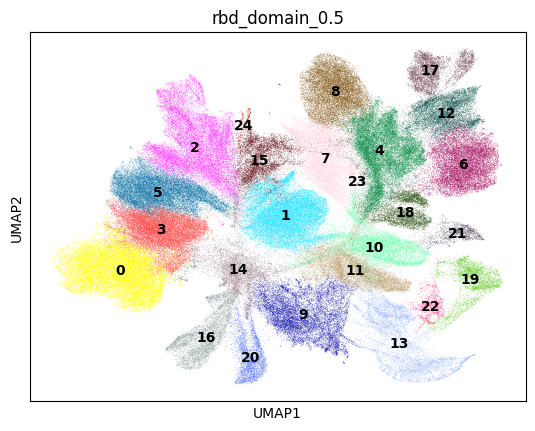

In [45]:
sc.pl.umap(adata_pseudobinned, color = 'rbd_domain_0.5', legend_loc = 'on data')